In [1]:
# =========================
# 0) CONFIG
# ========  =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/content/drive/MyDrive/DA6701_Ass1/"
RETURNS_PATH = DATA_DIR + "daily_returns.xlsx"
CATS_PATH    = DATA_DIR + "stock_categories.xlsx"

# Core assignment settings
N_SELECT = 10
RF_ANNUAL = 0.065
TRADING_DAYS = 252

# Monte Carlo settings (10 Lakh)
N_PORTFOLIOS = 1_000_000
CHUNK_SIZE = 200_000          # memory-safe batching
SEED = 42

# Plot settings
SCATTER_PLOT_POINTS = 120_000  # downsample for plotting so plot stays responsive
ENVELOPE_BINS = 250           # smooth frontier line
VOL_Q_LOW, VOL_Q_HIGH = 0.002, 0.998  # trim extreme vols when drawing envelope

In [2]:

# =========================
# 1) MOUNT DRIVE (Colab)
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# 2) LOAD DATA (robust loaders)
# =========================
def load_returns_xlsx(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)

    # Try to detect a date column
    date_col = None
    for c in df.columns:
        if isinstance(c, str) and "date" in c.lower():
            date_col = c
            break

    if date_col is not None:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)

    # Keep only numeric columns as returns
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    ret = df[num_cols].copy()
    ret = ret.replace([np.inf, -np.inf], np.nan).dropna(how="all")

    # Heuristic: if returns look like percentages (e.g., 2.3 for 2.3%), scale down
    q99 = ret.abs().quantile(0.99).max()
    if q99 is not None and q99 > 1.5:
        ret = ret / 100.0

    # Sort index if it's datetime
    try:
        ret = ret.sort_index()
    except Exception:
        pass

    return ret


def load_categories_xlsx(path: str, tickers: list[str]) -> pd.DataFrame:
    cats = pd.read_excel(path)
    cats.columns = [str(c).strip() for c in cats.columns]

    # Find the column that best matches tickers
    best_col = None
    best_match = -1
    ticker_set = set(tickers)
    for c in cats.columns:
        col_vals = set(cats[c].astype(str).str.strip().tolist())
        match = len(col_vals.intersection(ticker_set))
        if match > best_match:
            best_match = match
            best_col = c

    # Guess sector/category column
    sector_col = None
    for c in cats.columns:
        if isinstance(c, str) and any(k in c.lower() for k in ["sector", "category", "industry"]):
            sector_col = c
            break

    if best_col is None or best_match <= 0:
        # If we can't match, just return raw cats
        return cats

    out = cats[[best_col] + ([sector_col] if sector_col else [])].copy()
    out = out.rename(columns={best_col: "Ticker"})
    if sector_col:
        out = out.rename(columns={sector_col: "Sector"})
    out["Ticker"] = out["Ticker"].astype(str).str.strip()
    return out


returns_all = load_returns_xlsx(RETURNS_PATH)
tickers_all = list(returns_all.columns)

cats_df = load_categories_xlsx(CATS_PATH, tickers_all)

print("Returns shape:", returns_all.shape)
print("First 5 tickers:", tickers_all[:5])
display(cats_df.head())

Returns shape: (739, 30)
First 5 tickers: ['HDFCBANK', 'ICICIBANK', 'SBIN', 'TCS', 'INFY']


,Ticker,Sector
0,HDFCBANK,Banking & Finance
1,ICICIBANK,Banking & Finance
2,SBIN,Banking & Finance
3,TCS,Information Tech
4,INFY,Information Tech


In [4]:
# =========================
# 3) TRAIN/TEST SPLIT (optional but recommended)
#    Uses first ~2/3 as train, last ~1/3 as test
# =========================
n = len(returns_all)
split = int(0.67 * n)

returns_train_full = returns_all.iloc[:split].copy()
returns_test_full  = returns_all.iloc[split:].copy()

print("Train rows:", returns_train_full.shape[0], "Test rows:", returns_test_full.shape[0])

Train rows: 495 Test rows: 244


In [7]:
# =========================
# 4) OPTION A STOCK SELECTION (Greedy lowest avg |corr|)
# =========================
def select_stocks_option_A(returns: pd.DataFrame, k: int = 10) -> list[str]:
    # Use absolute correlation for diversification
    corr = returns.corr().abs()

    # Avg correlation to all others (exclude self)
    avg_corr = (corr.sum(axis=1) - 1.0) / (corr.shape[0] - 1.0)
    first = avg_corr.idxmin()

    selected = [first]
    remaining = set(corr.columns) - set(selected)

    print(f" 1: pick {first} (lowest avg |corr| = {avg_corr[first]:.4f})")

    while len(selected) < k:
        scores = {}
        for cand in remaining:
            scores[cand] = corr.loc[cand, selected].mean()
        nxt = min(scores, key=scores.get)
        print(f" {len(selected)+1}: pick {nxt} (mean |corr| to selected = {scores[nxt]:.4f})")
        selected.append(nxt)
        remaining.remove(nxt)

    return selected


# IMPORTANT: selection based on TRAIN data avoids look-ahead
selected10 = select_stocks_option_A(returns_train_full, k=N_SELECT)
print("\nSelected 10:", selected10)

 1: pick DMART (lowest avg |corr| = 0.1017)
 2: pick DRREDDY (mean |corr| to selected = 0.0022)
 3: pick ICICIBANK (mean |corr| to selected = 0.0150)
 4: pick BAJAJ-AUTO (mean |corr| to selected = 0.1120)
 5: pick TCS (mean |corr| to selected = 0.1089)
 6: pick INDUSTOWER (mean |corr| to selected = 0.1279)
 7: pick CIPLA (mean |corr| to selected = 0.1212)
 8: pick HINDUNILVR (mean |corr| to selected = 0.1078)
 9: pick POWERGRID (mean |corr| to selected = 0.1470)
 10: pick TRENT (mean |corr| to selected = 0.1632)

Selected 10: ['DMART', 'DRREDDY', 'ICICIBANK', 'BAJAJ-AUTO', 'TCS', 'INDUSTOWER', 'CIPLA', 'HINDUNILVR', 'POWERGRID', 'TRENT']


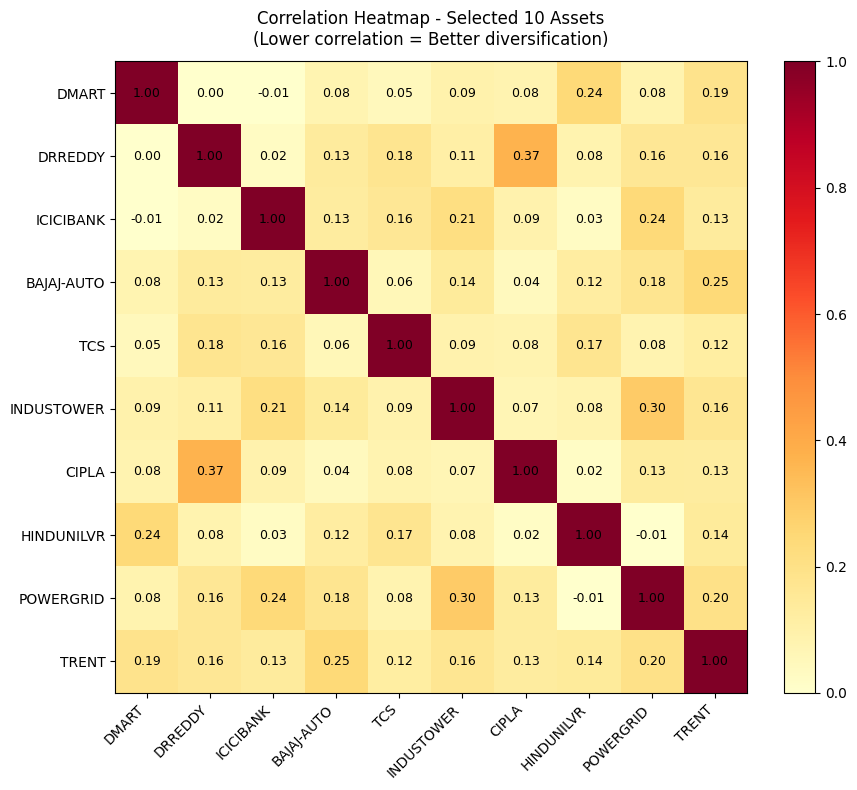

In [8]:
# =========================
# 5) CORRELATION HEATMAP (match shown format + colors)
# =========================
corr10 = returns_train_full[selected10].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Yellow -> Orange -> Red like the sample
im = ax.imshow(
    corr10.values,
    vmin=0.0, vmax=1.0,
    cmap="YlOrRd"
)

# ticks + labels
ax.set_xticks(np.arange(N_SELECT))
ax.set_yticks(np.arange(N_SELECT))
ax.set_xticklabels(selected10, rotation=45, ha="right")
ax.set_yticklabels(selected10)

# annotate values inside cells
for i in range(N_SELECT):
    for j in range(N_SELECT):
        ax.text(j, i, f"{corr10.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

# title
ax.set_title(
    "Correlation Heatmap - Selected 10 Assets\n(Lower correlation = Better diversification)",
    pad=12
)

# colorbar (0..1)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

In [9]:
# =========================
# 6) MPT INPUTS (mu, cov) ANNUALIZED (from TRAIN)
# =========================
R_train = returns_train_full[selected10].dropna(how="any")
mu_daily = R_train.mean().values
cov_daily = R_train.cov().values

mu_ann = mu_daily * TRADING_DAYS
cov_ann = cov_daily * TRADING_DAYS

print("mu_ann shape:", mu_ann.shape, "cov_ann shape:", cov_ann.shape)

mu_ann shape: (10,) cov_ann shape: (10, 10)


In [10]:
# =========================
# 7) MONTE CARLO (10 Lakh) LONG-ONLY, SUM=1
#    - finds GMV and Max Sharpe
#    - stores vol/ret/sharpe for analysis
# =========================
def run_monte_carlo(mu_ann, cov_ann, rf=0.065, n_port=1_000_000, chunk=200_000, seed=42):
    rng = np.random.default_rng(seed)
    n_assets = len(mu_ann)

    rets = np.empty(n_port, dtype=np.float32)
    vols = np.empty(n_port, dtype=np.float32)
    sharpes = np.empty(n_port, dtype=np.float32)

    best_sharpe = -np.inf
    best_sharpe_w = None
    best_sharpe_ret = None
    best_sharpe_vol = None

    best_gmv_vol = np.inf
    best_gmv_w = None
    best_gmv_ret = None

    cov = cov_ann.astype(np.float64)
    mu = mu_ann.astype(np.float64)

    idx = 0
    while idx < n_port:
        m = min(chunk, n_port - idx)

        # Dirichlet -> nonnegative weights summing to 1
        W = rng.dirichlet(alpha=np.ones(n_assets), size=m).astype(np.float32)

        # Portfolio return (annual)
        pret = (W @ mu).astype(np.float32)

        # Portfolio variance (annual): diag(W * cov * W^T)
        # einsum is fast & memory-safe
        pvar = np.einsum("ij,jk,ik->i", W.astype(np.float64), cov, W.astype(np.float64))
        pvol = np.sqrt(np.maximum(pvar, 1e-18)).astype(np.float32)

        psh = ((pret - rf) / np.maximum(pvol, 1e-12)).astype(np.float32)

        rets[idx:idx+m] = pret
        vols[idx:idx+m] = pvol
        sharpes[idx:idx+m] = psh

        # Update best Sharpe
        local_max = int(np.argmax(psh))
        if psh[local_max] > best_sharpe:
            best_sharpe = float(psh[local_max])
            best_sharpe_w = W[local_max].copy()
            best_sharpe_ret = float(pret[local_max])
            best_sharpe_vol = float(pvol[local_max])

        # Update GMV (min vol)
        local_min = int(np.argmin(pvol))
        if pvol[local_min] < best_gmv_vol:
            best_gmv_vol = float(pvol[local_min])
            best_gmv_w = W[local_min].copy()
            best_gmv_ret = float(pret[local_min])

        idx += m

    out = {
        "rets": rets, "vols": vols, "sharpes": sharpes,
        "gmv": {"w": best_gmv_w, "ret": best_gmv_ret, "vol": best_gmv_vol},
        "maxsharpe": {"w": best_sharpe_w, "ret": best_sharpe_ret, "vol": best_sharpe_vol, "sharpe": best_sharpe},
    }
    return out


mc = run_monte_carlo(mu_ann, cov_ann, rf=RF_ANNUAL, n_port=N_PORTFOLIOS, chunk=CHUNK_SIZE, seed=SEED)

print("GMV:", mc["gmv"])
print("MaxSharpe:", {k: mc["maxsharpe"][k] for k in ["ret","vol","sharpe"]})

GMV: {'w': array([0.08407269, 0.12489995, 0.2313147 , 0.04390896, 0.1792955 ,
       0.0045677 , 0.09944405, 0.21011445, 0.01478718, 0.00759481],
      dtype=float32), 'ret': 0.16862908005714417, 'vol': 0.10075313597917557}
MaxSharpe: {'ret': 0.5697854161262512, 'vol': 0.18655948340892792, 'sharpe': 2.705761194229126}


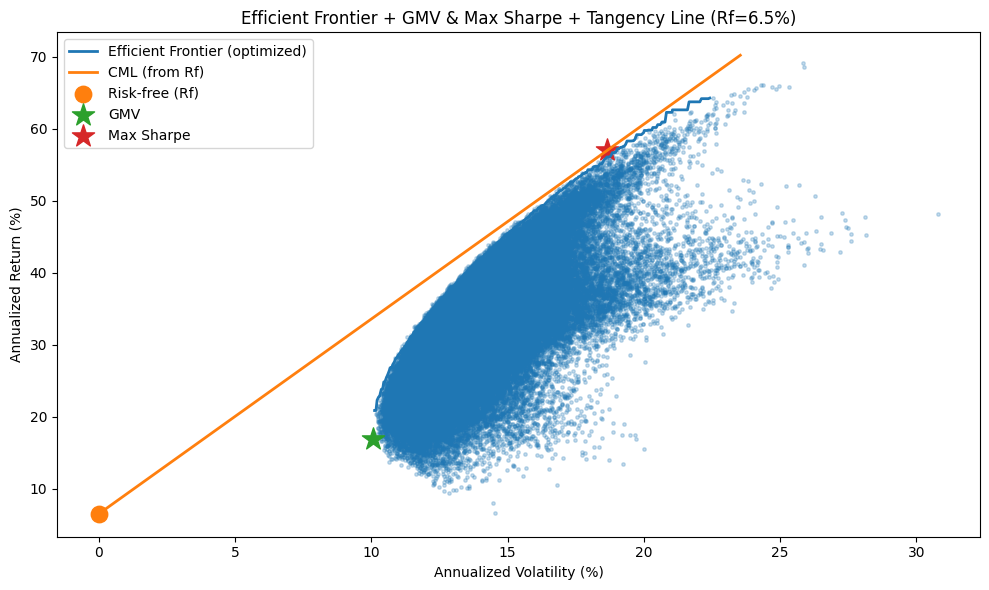

In [11]:
# =========================
# 8) CLEAN FRONTIER LINE (Robust Envelope) + CML + PLOTS (match expected)
# =========================
def upper_envelope(vols, rets, bins=250, qlow=0.0, qhigh=0.999, r_quant=0.995):
    v = vols.astype(np.float64)
    r = rets.astype(np.float64)

    # Trim only extreme vols (keep left tail so GMV doesn't fall "outside" the curve)
    vmin = np.quantile(v, qlow)
    vmax = np.quantile(v, qhigh)

    mask = (v >= vmin) & (v <= vmax) & np.isfinite(v) & np.isfinite(r)
    v = v[mask]; r = r[mask]

    edges = np.linspace(v.min(), v.max(), bins + 1)
    b = np.clip(np.digitize(v, edges) - 1, 0, bins - 1)

    best_v = np.full(bins, np.nan)
    best_r = np.full(bins, np.nan)

    # Robust: use a high-quantile return per bin (instead of max) to avoid outlier-driven "parabola"
    for i in range(bins):
        m = (b == i)
        if np.any(m):
            ri = r[m]
            vi = v[m]
            thr = np.quantile(ri, r_quant)
            top = ri >= thr
            best_r[i] = ri[top].mean()
            best_v[i] = vi[top].mean()

    ok = np.isfinite(best_v) & np.isfinite(best_r)
    best_v = best_v[ok]
    best_r = best_r[ok]

    order = np.argsort(best_v)
    best_v = best_v[order]
    best_r = best_r[order]

    # Smooth frontier-like: enforce non-decreasing return
    best_r = np.maximum.accumulate(best_r)

    return best_v, best_r


vols = mc["vols"]
rets = mc["rets"]

# Downsample for scatter plot
rng = np.random.default_rng(SEED)
plot_n = min(SCATTER_PLOT_POINTS, len(vols))
plot_idx = rng.choice(len(vols), size=plot_n, replace=False)

# Envelope (robust) — keep GMV inside the curve
env_v, env_r = upper_envelope(
    vols, rets,
    bins=ENVELOPE_BINS,
    qlow=0.0, qhigh=VOL_Q_HIGH,     # IMPORTANT: qlow=0.0 so left tail (GMV) is not chopped off
    r_quant=0.995
)

# Points
rf = RF_ANNUAL
v_gmv, r_gmv = mc["gmv"]["vol"], mc["gmv"]["ret"]
v_ms,  r_ms  = mc["maxsharpe"]["vol"], mc["maxsharpe"]["ret"]

# Capital Market Line through tangency (max Sharpe) portfolio
slope = (r_ms - rf) / max(v_ms, 1e-12)
cml_v = np.linspace(0.0, max(env_v.max(), v_ms) * 1.05, 200)
cml_r = rf + slope * cml_v

# Plot in % to match expected figure
to_pct = 100.0
plt.figure(figsize=(10, 6))

plt.scatter(vols[plot_idx] * to_pct, rets[plot_idx] * to_pct, s=6, alpha=0.25, marker="o")
plt.plot(env_v * to_pct, env_r * to_pct, linewidth=2, label="Efficient Frontier (optimized)")
plt.plot(cml_v * to_pct, cml_r * to_pct, linewidth=2, label="CML (from Rf)")

plt.scatter([0.0], [rf * to_pct], s=140, label="Risk-free (Rf)")
plt.scatter([v_gmv * to_pct], [r_gmv * to_pct], marker="*", s=280, label="GMV")
plt.scatter([v_ms  * to_pct], [r_ms  * to_pct], marker="*", s=280, label="Max Sharpe")

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title(f"Efficient Frontier + GMV & Max Sharpe + Tangency Line (Rf={rf*100:.1f}%)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# =========================
# 9) WEIGHTS TABLE (GMV vs MaxSharpe)
# =========================
w_gmv = mc["gmv"]["w"]
w_ms  = mc["maxsharpe"]["w"]

weights_df = pd.DataFrame({
    "Ticker": selected10,
    "GMV_weight": w_gmv,
    "MaxSharpe_weight": w_ms
})
weights_df["GMV_weight"] = weights_df["GMV_weight"].round(6)
weights_df["MaxSharpe_weight"] = weights_df["MaxSharpe_weight"].round(6)

display(weights_df)

print("Sum GMV weights:", float(np.sum(w_gmv)))
print("Sum MaxSharpe weights:", float(np.sum(w_ms)))
print("Min weight GMV:", float(np.min(w_gmv)), "Min weight MaxSharpe:", float(np.min(w_ms)))

,Ticker,GMV_weight,MaxSharpe_weight
0,DMART,0.084073,0.015626
1,DRREDDY,0.124900,0.001064
2,ICICIBANK,0.231315,0.116100
3,BAJAJ-AUTO,0.043909,0.263670
4,TCS,0.179296,0.006344
5,INDUSTOWER,0.004568,0.103911
6,CIPLA,0.099444,0.053869
7,HINDUNILVR,0.210114,0.004073
8,POWERGRID,0.014787,0.050630
9,TRENT,0.007595,0.384712


Sum GMV weights: 1.0
Sum MaxSharpe weights: 1.0
Min weight GMV: 0.004567704629153013 Min weight MaxSharpe: 0.0010636246297508478


In [13]:
# --- Create R_train / R_test in the same style as your R_train definition ---
R_train = returns_train_full[selected10].replace([np.inf, -np.inf], np.nan).dropna(how="any")
R_test  = returns_test_full[selected10].replace([np.inf, -np.inf], np.nan).dropna(how="any")

print("Train usable rows:", len(R_train), "Test usable rows:", len(R_test))

Train usable rows: 495 Test usable rows: 244



1. Performance Metrics (In-Sample):



,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Win Rate,VaR 95%,CVaR 95%
GMV,17.76%,10.08%,1.049,1.806,-13.79%,1.289,54.95%,-16.08%,-19.12%
Max Sharpe,73.66%,18.66%,2.717,4.187,-25.13%,2.931,61.01%,-24.72%,-37.61%
Equal Weight,35.62%,11.92%,2.088,3.099,-18.17%,1.960,58.79%,-18.27%,-25.38%



2. Cumulative Performance (In-Sample):



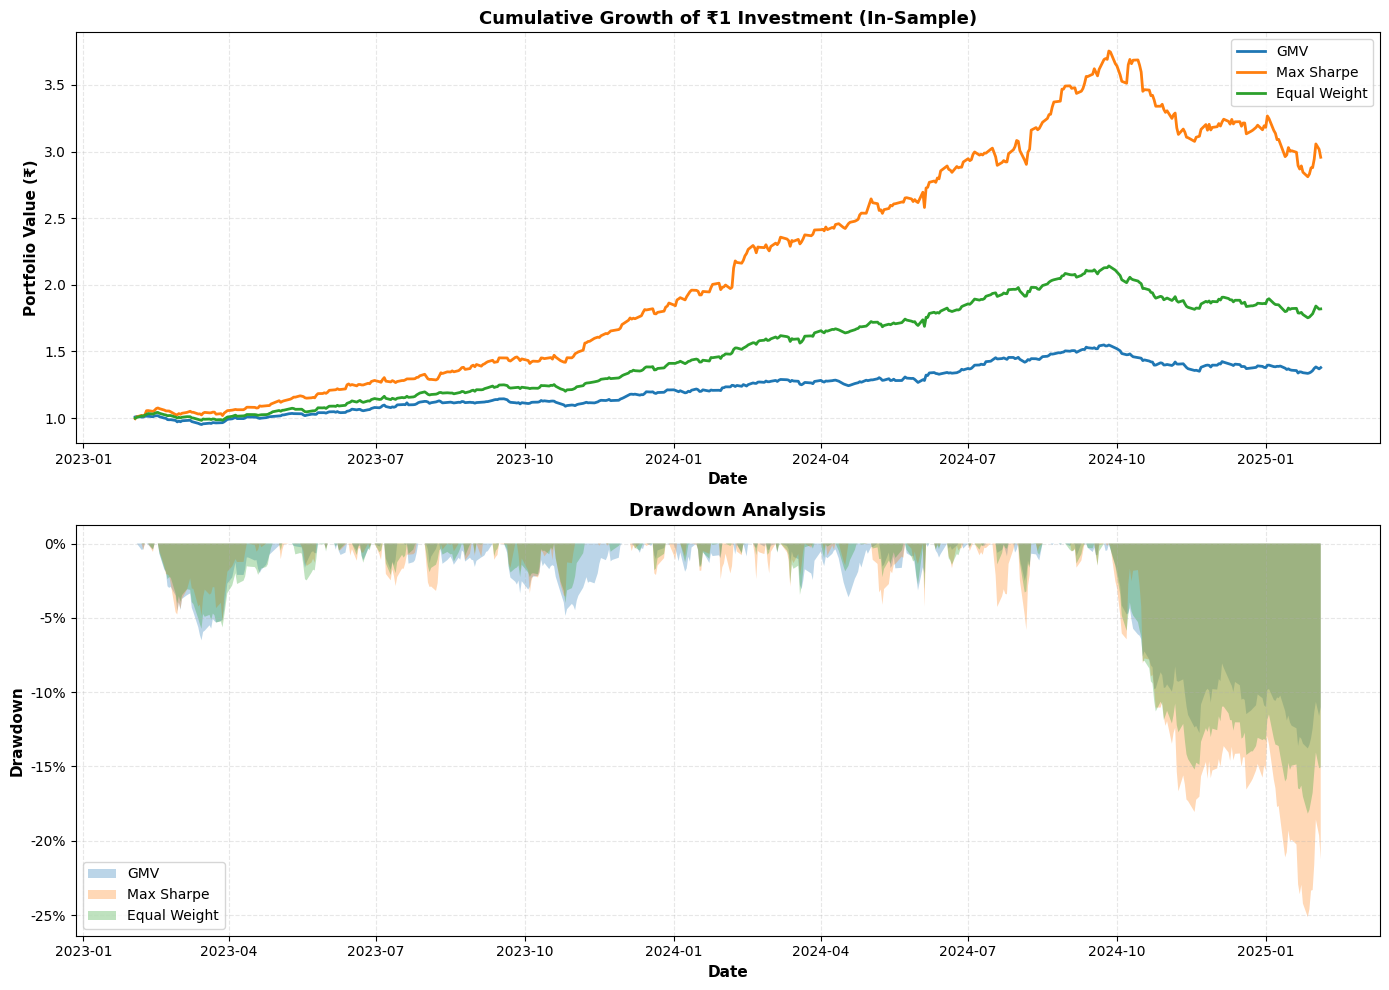


3. Rolling Performance (90-day window) (In-Sample):



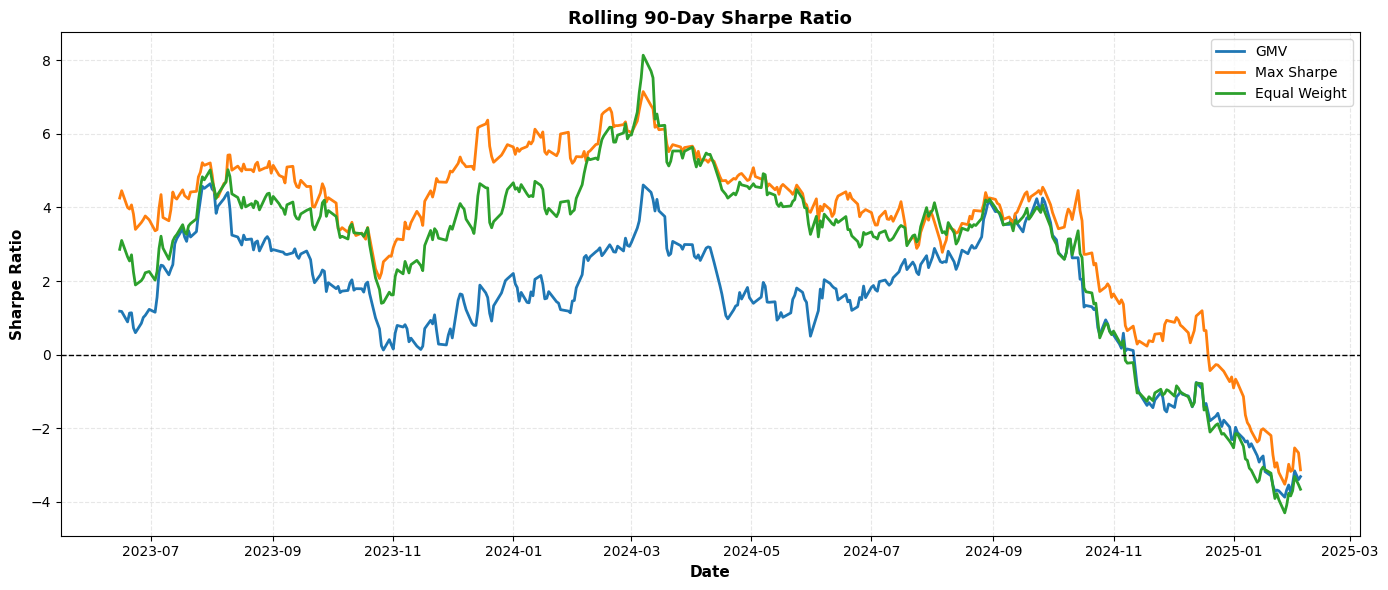


1. Performance Metrics (Out-of-Sample (Test)):



,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Win Rate,VaR 95%,CVaR 95%
GMV,-2.71%,11.05%,-0.764,-1.320,-8.96%,-0.303,46.72%,-16.68%,-22.02%
Max Sharpe,-9.06%,19.70%,-0.703,-0.913,-16.66%,-0.543,45.90%,-29.13%,-45.91%
Equal Weight,-3.00%,12.58%,-0.680,-1.048,-10.00%,-0.301,44.67%,-18.38%,-27.96%



2. Cumulative Performance (Out-of-Sample (Test)):



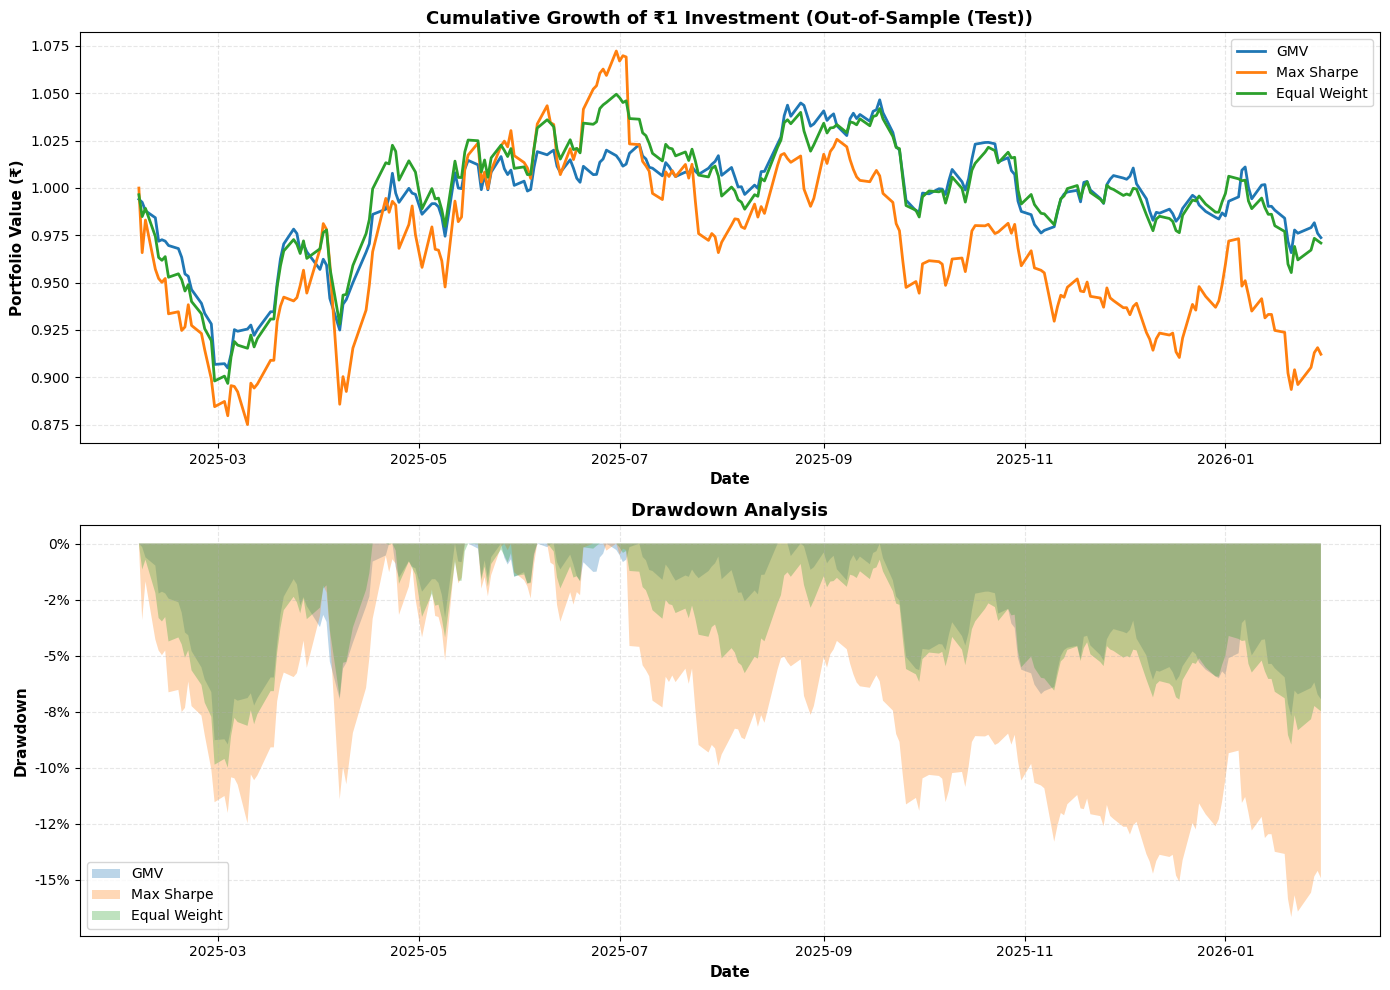


3. Rolling Performance (90-day window) (Out-of-Sample (Test)):



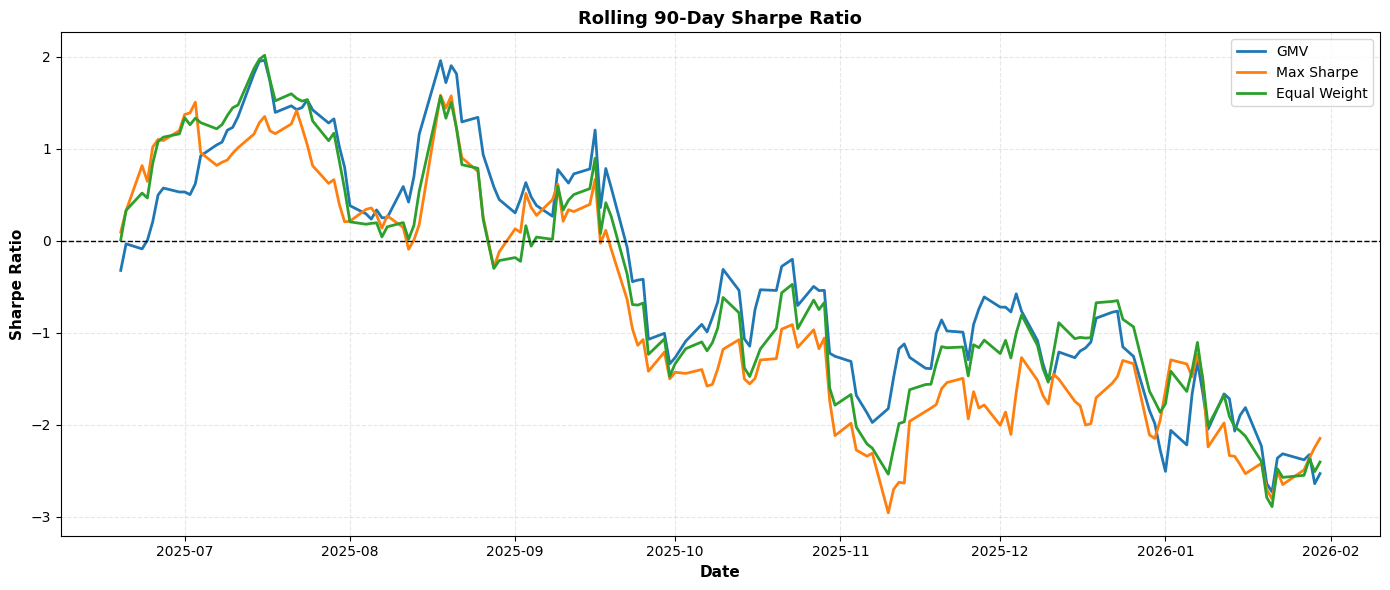

(              Annual Return  Annual Volatility  Sharpe Ratio  Sortino Ratio  \
 GMV               -0.027110           0.110494     -0.763819      -1.320415   
 Max Sharpe        -0.090558           0.196993     -0.702630      -0.913496   
 Equal Weight      -0.030050           0.125841     -0.680281      -1.048392   
 
               Max Drawdown  Calmar Ratio  Win Rate   VaR 95%  CVaR 95%  
 GMV              -0.089610     -0.302534  0.467213 -0.166757 -0.220164  
 Max Sharpe       -0.166623     -0.543488  0.459016 -0.291279 -0.459074  
 Equal Weight     -0.099952     -0.300643  0.446721 -0.183767 -0.279560  ,
                  GMV  Max Sharpe  Equal Weight
 Date                                          
 2025-02-05 -0.005990   -0.000097     -0.003617
 2025-02-06 -0.001603   -0.034106     -0.011578
 2025-02-07 -0.004555    0.017834      0.004413
 2025-02-10 -0.003708   -0.026366     -0.014941
 2025-02-11 -0.012582   -0.005169     -0.011434
 ...              ...         ...           .

In [14]:

def calculate_portfolio_returns(returns_df, weights):
    """Calculate portfolio returns given weights (ABCD style)"""
    return (returns_df @ weights).rename(weights.name)

def calculate_performance_metrics(returns, rf_annual=RF_ANNUAL, trading_days=TRADING_DAYS):
    """Calculate comprehensive performance metrics (ABCD style)"""

    # Annualized return (geometric)
    cumulative_return = (1 + returns).prod()
    n_years = len(returns) / trading_days
    annual_return = cumulative_return ** (1/n_years) - 1

    # Annualized volatility
    annual_vol = returns.std() * np.sqrt(trading_days)

    # Sharpe Ratio (ABCD uses returns.std(), not excess std)
    rf_daily = (1 + rf_annual) ** (1/trading_days) - 1
    excess_returns = returns - rf_daily
    sharpe = excess_returns.mean() / (returns.std() + 1e-12) * np.sqrt(trading_days)

    # Sortino Ratio (ABCD uses downside deviation of *raw returns*, not excess)
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() if len(downside_returns) > 0 else 0
    sortino = excess_returns.mean() / (downside_std + 1e-12) * np.sqrt(trading_days)

    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    # Calmar Ratio (Return / MaxDD)
    calmar = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

    # Win Rate
    win_rate = (returns > 0).sum() / len(returns)

    # Value at Risk (95%)
    var_95 = returns.quantile(0.05)

    # Conditional VaR (Expected Shortfall)
    cvar_95 = returns[returns <= var_95].mean()

    return {
        'Annual Return': annual_return,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
        'Win Rate': win_rate,
        'VaR 95%': var_95 * np.sqrt(trading_days),  # Annualized
        'CVaR 95%': cvar_95 * np.sqrt(trading_days)  # Annualized
    }

def abcd_backtest_block(R_selected, title_tag="In-Sample"):
    # Build weights as pandas Series with names (ABCD expects this)
    w_gmv = pd.Series(mc["gmv"]["w"], index=selected10, name="GMV")
    w_msr = pd.Series(mc["maxsharpe"]["w"], index=selected10, name="Max Sharpe")
    w_eq  = pd.Series(np.ones(len(selected10))/len(selected10), index=selected10, name="Equal Weight")

    # Generate portfolio return series
    port_gmv = calculate_portfolio_returns(R_selected, w_gmv)
    port_msr = calculate_portfolio_returns(R_selected, w_msr)
    port_eq  = calculate_portfolio_returns(R_selected, w_eq)

    # Combine into dataframe
    portfolio_returns = pd.concat([port_gmv, port_msr, port_eq], axis=1)

    # Calculate metrics for all portfolios
    print(f"\n1. Performance Metrics ({title_tag}):\n")
    metrics_df = pd.DataFrame({
        col: calculate_performance_metrics(portfolio_returns[col])
        for col in portfolio_returns.columns
    }).T

    # Format for display
    metrics_display = metrics_df.copy()
    for col in ['Annual Return', 'Annual Volatility', 'Max Drawdown', 'Win Rate', 'VaR 95%', 'CVaR 95%']:
        metrics_display[col] = metrics_display[col].apply(lambda x: f'{x:.2%}')
    for col in ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']:
        metrics_display[col] = metrics_display[col].apply(lambda x: f'{x:.3f}')

    display(metrics_display)

    # Cumulative return visualization
    print(f"\n2. Cumulative Performance ({title_tag}):\n")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Cumulative returns
    cumulative = (1 + portfolio_returns).cumprod()
    for col in cumulative.columns:
        ax1.plot(cumulative.index, cumulative[col], label=col, linewidth=2)

    ax1.set_title(f'Cumulative Growth of ₹1 Investment ({title_tag})', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Portfolio Value (₹)', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xlabel('Date', fontsize=11, fontweight='bold')

    # Drawdown chart
    for col in portfolio_returns.columns:
        cum = (1 + portfolio_returns[col]).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.3, label=col)

    ax2.set_title('Drawdown Analysis', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Drawdown', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    plt.tight_layout()
    plt.show()

    # Rolling Sharpe Ratio
    print(f"\n3. Rolling Performance (90-day window) ({title_tag}):\n")
    rolling_window = 90

    fig, ax = plt.subplots(figsize=(14, 6))
    for col in portfolio_returns.columns:
        rf_daily = (1 + RF_ANNUAL) ** (1/TRADING_DAYS) - 1
        excess = portfolio_returns[col] - rf_daily
        rolling_sharpe = (excess.rolling(rolling_window).mean() /
                          portfolio_returns[col].rolling(rolling_window).std() *
                          np.sqrt(TRADING_DAYS))
        ax.plot(rolling_sharpe.index, rolling_sharpe, label=col, linewidth=2)

    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Rolling {rolling_window}-Day Sharpe Ratio', fontsize=13, fontweight='bold')
    ax.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return metrics_df, portfolio_returns



abcd_backtest_block(R_train, title_tag="In-Sample")

# =========================
# OPTIONAL (EXTENSION): RUN THE SAME ABCD TESTING ON OUT-OF-SAMPLE TEST
# =========================
R_test = returns_test_full[selected10].dropna(how="any")
abcd_backtest_block(R_test, title_tag="Out-of-Sample (Test)")